# 🧠 Oxford Parkinson's Vocal Biomarkers — Exploratory Data Analysis & Visualization
### Minor Project Part-I: Acoustic Voice Analysis
**Dataset:** Oxford Parkinson's Disease Telemonitoring Dataset (195 voice recordings, 22 acoustic features + 1 target)  
**Tools:** `matplotlib`, `seaborn`, `pandas`, `numpy`  
**Purpose:** Visualize vocal impairment patterns, fundamental frequency dysregulation, jitter, shimmer, harmonics-to-noise ratios, and pitch period entropy.

## 1. Setup & Data Loading
Configure aesthetic parameters and load the cleaned dataset.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.autolayout'] = True
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "processed_data", "cleaned_parkinsons.csv")
VIZ_DIR = os.path.join(BASE_DIR, "visualizations", "parkinsons")
os.makedirs(VIZ_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded Parkinson's Cleaned Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Loaded Parkinson's Cleaned Dataset: 195 rows, 23 columns


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 2. Cohort Status Distribution
Examine diagnostic status distribution (`0 = Healthy Control`, `1 = Parkinson's Disease Patient`).

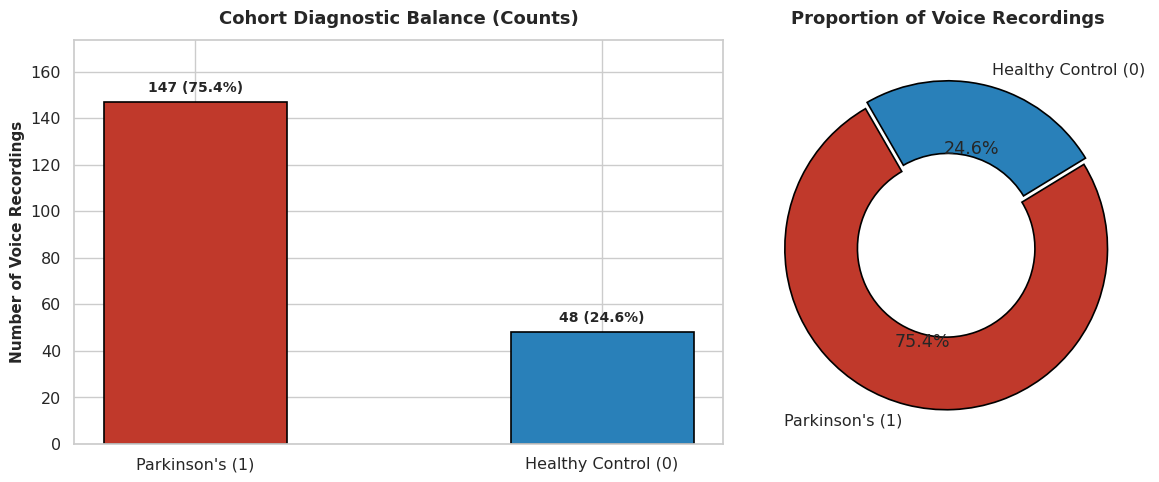

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_counts = df['status'].value_counts()
labels = ["Parkinson's (1)", 'Healthy Control (0)']
counts = [status_counts[1], status_counts[0]]
colors = ['#c0392b', '#2980b9']

# 1. Bar Chart
bars = axes[0].bar(labels, counts, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
axes[0].set_title("Cohort Diagnostic Balance (Counts)", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("Number of Voice Recordings", fontsize=11, fontweight='bold')
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                 f"{c} ({c/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.18)

# 2. Donut Chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=120, colors=colors,
            explode=(0.04, 0), wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.2))
axes[1].set_title("Proportion of Voice Recordings", fontsize=13, fontweight='bold', pad=12)

plt.savefig(os.path.join(VIZ_DIR, "01_status_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Fundamental Vocal Frequencies (`Fo`, `Fhi`, `Flo`)
Analyze differences in vocal fundamental frequencies between Parkinson's patients and healthy controls:
* `MDVP:Fo(Hz)` — Average vocal fundamental frequency
* `MDVP:Fhi(Hz)` — Maximum vocal fundamental frequency
* `MDVP:Flo(Hz)` — Minimum vocal fundamental frequency

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\2261451959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, ax=ax, palette=['#2980b9', '#c0392b'],
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\2261451959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, ax=ax, palette=['#2980b9', '#c0392b'],


C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\2261451959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, ax=ax, palette=['#2980b9', '#c0392b'],


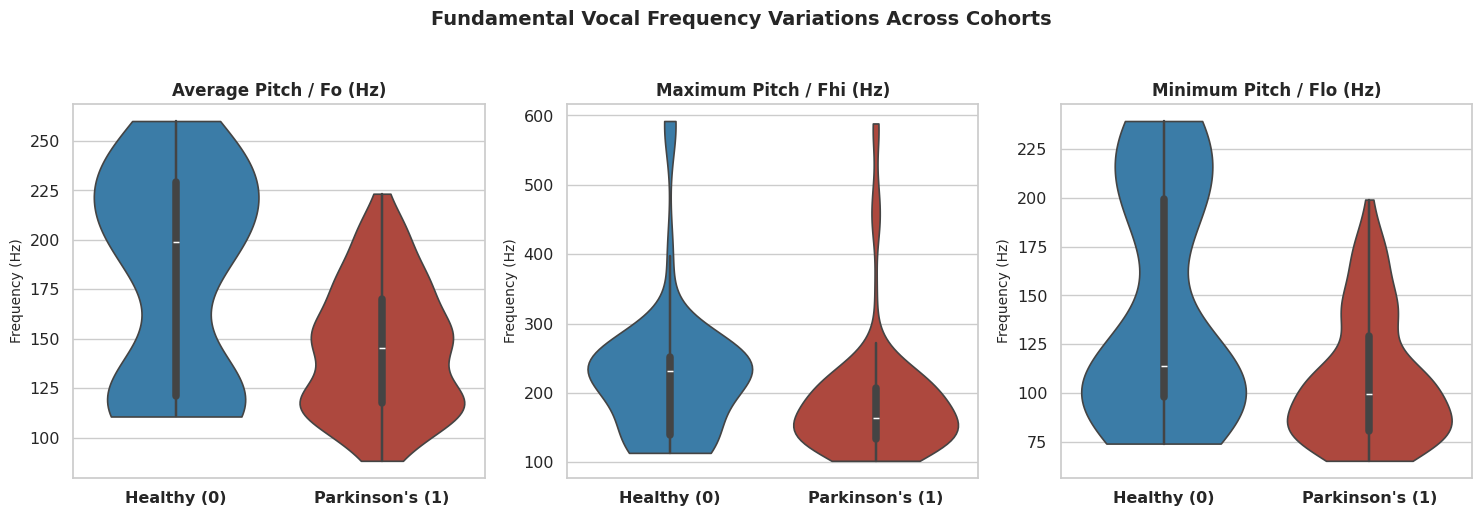

In [3]:
freq_features = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
freq_labels = {
    'MDVP:Fo(Hz)': 'Average Pitch / Fo (Hz)',
    'MDVP:Fhi(Hz)': 'Maximum Pitch / Fhi (Hz)',
    'MDVP:Flo(Hz)': 'Minimum Pitch / Flo (Hz)'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(freq_features):
    ax = axes[idx]
    sns.violinplot(data=df, x='status', y=col, ax=ax, palette=['#2980b9', '#c0392b'],
                   inner='box', cut=0, linewidth=1.2)
    ax.set_title(freq_labels[col], fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Frequency (Hz)", fontsize=10)

plt.suptitle("Fundamental Vocal Frequency Variations Across Cohorts", fontsize=14, fontweight='bold', y=1.03)
plt.savefig(os.path.join(VIZ_DIR, "02_fundamental_frequencies.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Key Nonlinear & Acoustic Biomarkers
Investigate the strongest diagnostic markers discovered in vocal telemonitoring:
* **Pitch Period Entropy (`PPE`):** Measures impaired pitch control.
* **Spread1:** Nonlinear measure of fundamental frequency variation.
* **Harmonics-to-Noise Ratio (`HNR`):** Ratio of acoustic harmonics to tonal noise in dB.

C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\3359097774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='PPE', ax=axes[0], palette=['#2980b9', '#c0392b'],
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\3359097774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='spread1', ax=axes[1], palette=['#2980b9', '#c0392b'],
C:\Users\Lakshya\AppData\Local\Temp\ipykernel_17428\3359097774.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='HNR', ax=axes[2], palett

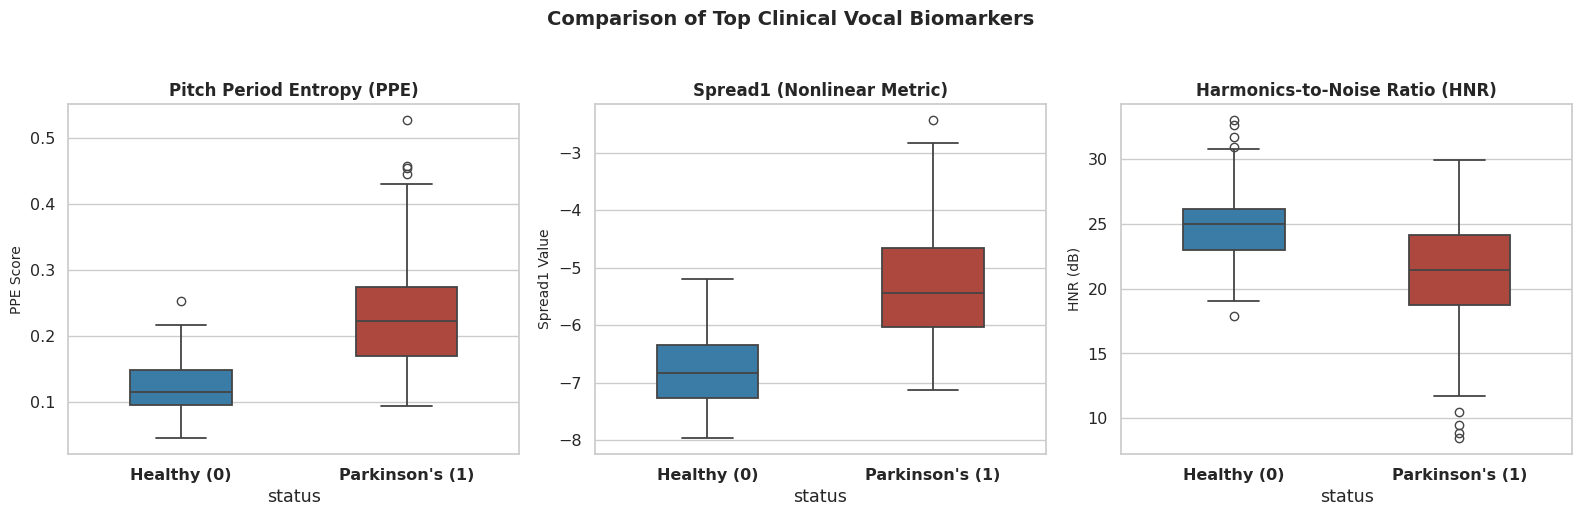

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='status', y='PPE', ax=axes[0], palette=['#2980b9', '#c0392b'],
            linewidth=1.3, width=0.45)
axes[0].set_title("Pitch Period Entropy (PPE)", fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontweight='bold')
axes[0].set_ylabel("PPE Score", fontsize=10)

sns.boxplot(data=df, x='status', y='spread1', ax=axes[1], palette=['#2980b9', '#c0392b'],
            linewidth=1.3, width=0.45)
axes[1].set_title("Spread1 (Nonlinear Metric)", fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontweight='bold')
axes[1].set_ylabel("Spread1 Value", fontsize=10)

sns.boxplot(data=df, x='status', y='HNR', ax=axes[2], palette=['#2980b9', '#c0392b'],
            linewidth=1.3, width=0.45)
axes[2].set_title("Harmonics-to-Noise Ratio (HNR)", fontsize=12, fontweight='bold')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontweight='bold')
axes[2].set_ylabel("HNR (dB)", fontsize=10)

plt.suptitle("Comparison of Top Clinical Vocal Biomarkers", fontsize=14, fontweight='bold', y=1.03)
plt.savefig(os.path.join(VIZ_DIR, "03_nonlinear_biomarkers.png"), dpi=300, bbox_inches='tight')
plt.show()

## 5. Acoustic Correlation Matrix
Examine relationships between Jitter (frequency perturbation), Shimmer (amplitude perturbation), and Parkinson's diagnosis.

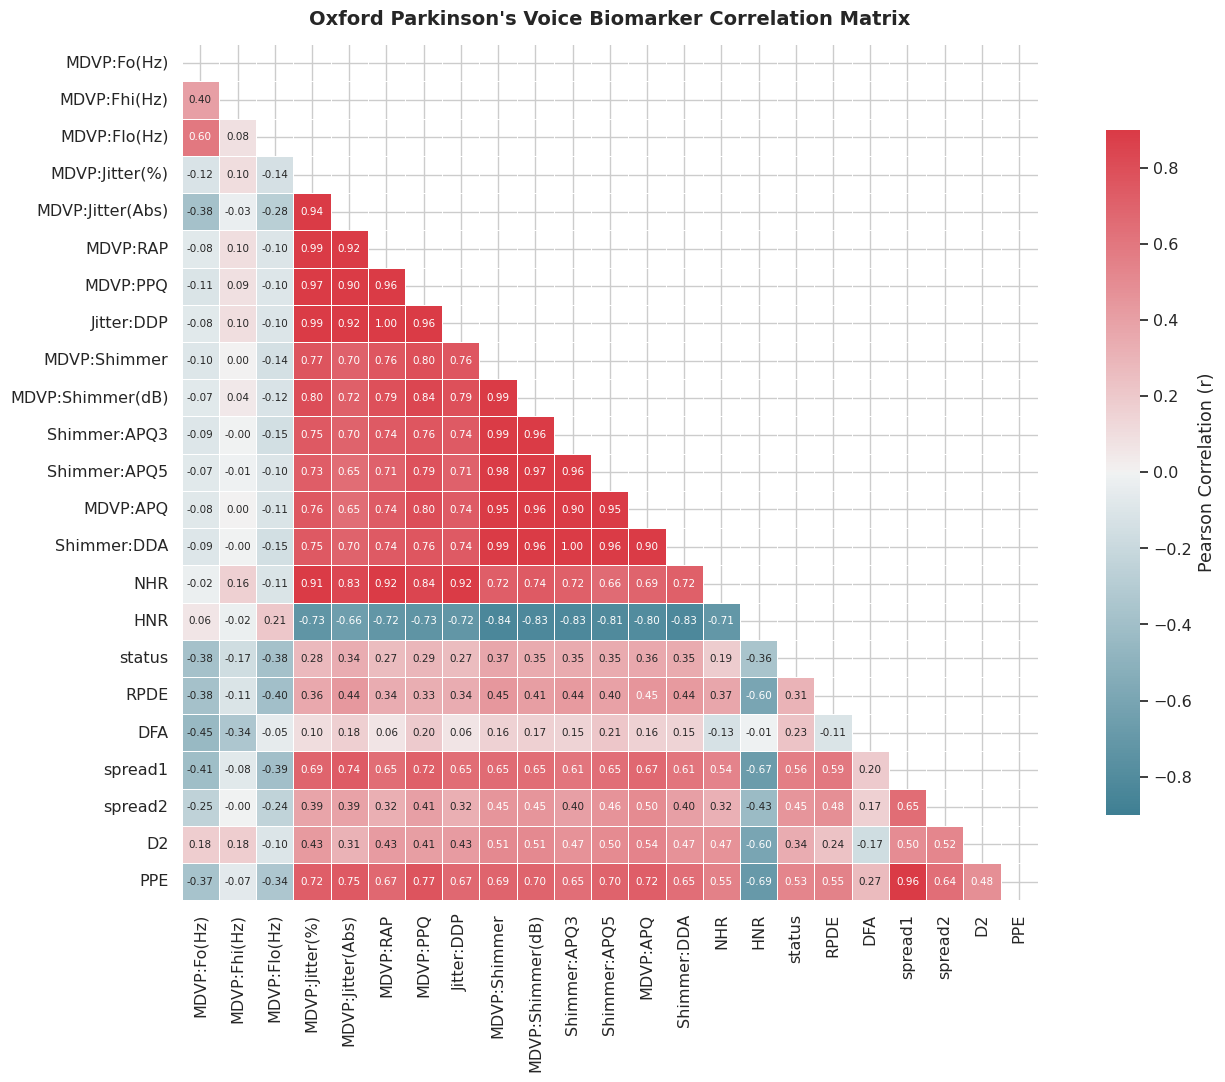

--- Top Correlates with Parkinson's Status ---


,Correlation with Status
status,1.000000
spread1,0.564838
PPE,0.531039
spread2,0.454842
MDVP:Shimmer,0.367430
MDVP:APQ,0.364316
Shimmer:APQ5,0.351148
MDVP:Shimmer(dB),0.350697
Shimmer:APQ3,0.347617
Shimmer:DDA,0.347608


In [5]:
plt.figure(figsize=(14, 11))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.9, vmin=-.9, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7.5}, square=True, linewidths=.5,
            cbar_kws={"shrink": .8, "label": "Pearson Correlation (r)"})

plt.title("Oxford Parkinson's Voice Biomarker Correlation Matrix", fontsize=14, fontweight='bold', pad=14)
plt.savefig(os.path.join(VIZ_DIR, "04_acoustic_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

print("--- Top Correlates with Parkinson's Status ---")
display(corr['status'].sort_values(ascending=False).to_frame(name="Correlation with Status"))

## 6. Scatter Separation: Pitch Period Entropy (`PPE`) vs `spread1`
Visualize cluster separation between healthy subjects and Parkinson's patients in nonlinear acoustic feature space.

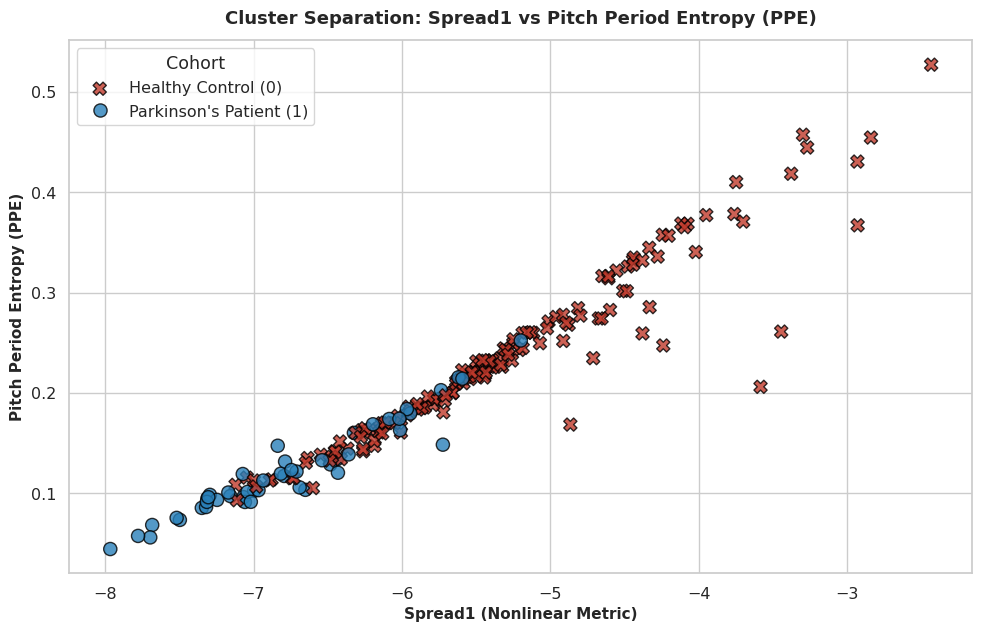

In [6]:
plt.figure(figsize=(10, 6.5))

sns.scatterplot(data=df, x='spread1', y='PPE', hue='status', style='status',
                palette=['#2980b9', '#c0392b'], s=90, alpha=0.8, edgecolor='black', linewidth=1)

plt.title("Cluster Separation: Spread1 vs Pitch Period Entropy (PPE)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Spread1 (Nonlinear Metric)", fontsize=11, fontweight='bold')
plt.ylabel("Pitch Period Entropy (PPE)", fontsize=11, fontweight='bold')
plt.legend(title="Cohort", labels=['Healthy Control (0)', "Parkinson's Patient (1)"], loc='upper left')

plt.savefig(os.path.join(VIZ_DIR, "05_ppe_vs_spread1_separation.png"), dpi=300, bbox_inches='tight')
plt.show()

## 7. Key Vocal Analysis Findings
* **Nonlinear Markers (`PPE`, `spread1`):** Show the sharpest separation with Parkinson's diagnosis ($r > 0.53$).
* **Harmonics-to-Noise Ratio (`HNR`):** Significantly lower in Parkinson's patients, confirming increased breathiness and acoustic noise.
* **Jitter & Shimmer:** Show elevated values indicating severe phonatory instability in affected patients.